# Combined Correlation Analysis Per Video: Pose + MoLab vs IRAF SAT (n=10)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

FEATURES_DIR = '../data/processed/features/'
OUT_DIR      = '../data/processed/features/combined/per_video/'
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
pose  = pd.read_csv(FEATURES_DIR + 'pose/per_video/correlation_results.csv').assign(source='Pose')
molab = pd.read_csv(FEATURES_DIR + 'molab/per_video/molab_correlation_results.csv').assign(source='MoLab')

combined = pd.concat([pose, molab], ignore_index=True)
combined.to_csv(OUT_DIR + 'combined_correlation_results.csv', index=False)
print(f'Pose: {len(pose)} rows, MoLab: {len(molab)} rows, Combined: {len(combined)} rows')


Pose: 120 rows, MoLab: 80 rows, Combined: 200 rows


In [3]:
top = (combined
    .assign(abs_rho=combined['spearman_rho'].abs())
    .sort_values('abs_rho', ascending=False)
    .drop(columns='abs_rho')
    .head(20)
    .reset_index(drop=True))
top


,feature,iraf_score,spearman_rho,p_value,source
0,peak_pelvis_gyro,iraf_total,0.857147,0.001528,MoLab
1,forb_peak_pelvis_gyro,iraf_total,0.857147,0.001528,MoLab
2,delta_pelvis_tilt,iraf_utgångsposition,0.842424,0.002220,MoLab
3,peak_pelvis_gyro,iraf_utgångsposition,0.830303,0.002940,MoLab
4,forb_peak_pelvis_gyro,iraf_utgångsposition,0.830303,0.002940,MoLab
5,mean_trunk_angle,iraf_total,0.808514,0.004635,Pose
6,initial_trunk_angle,iraf_total,0.808514,0.004635,Pose
7,initial_trunk_angle,iraf_utgångsposition,0.806061,0.004862,Pose
8,mean_trunk_angle,iraf_utgångsposition,0.806061,0.004862,Pose
9,forb_peak_pelvis_gyro,iraf_rörelseutförande,0.790259,0.006516,MoLab


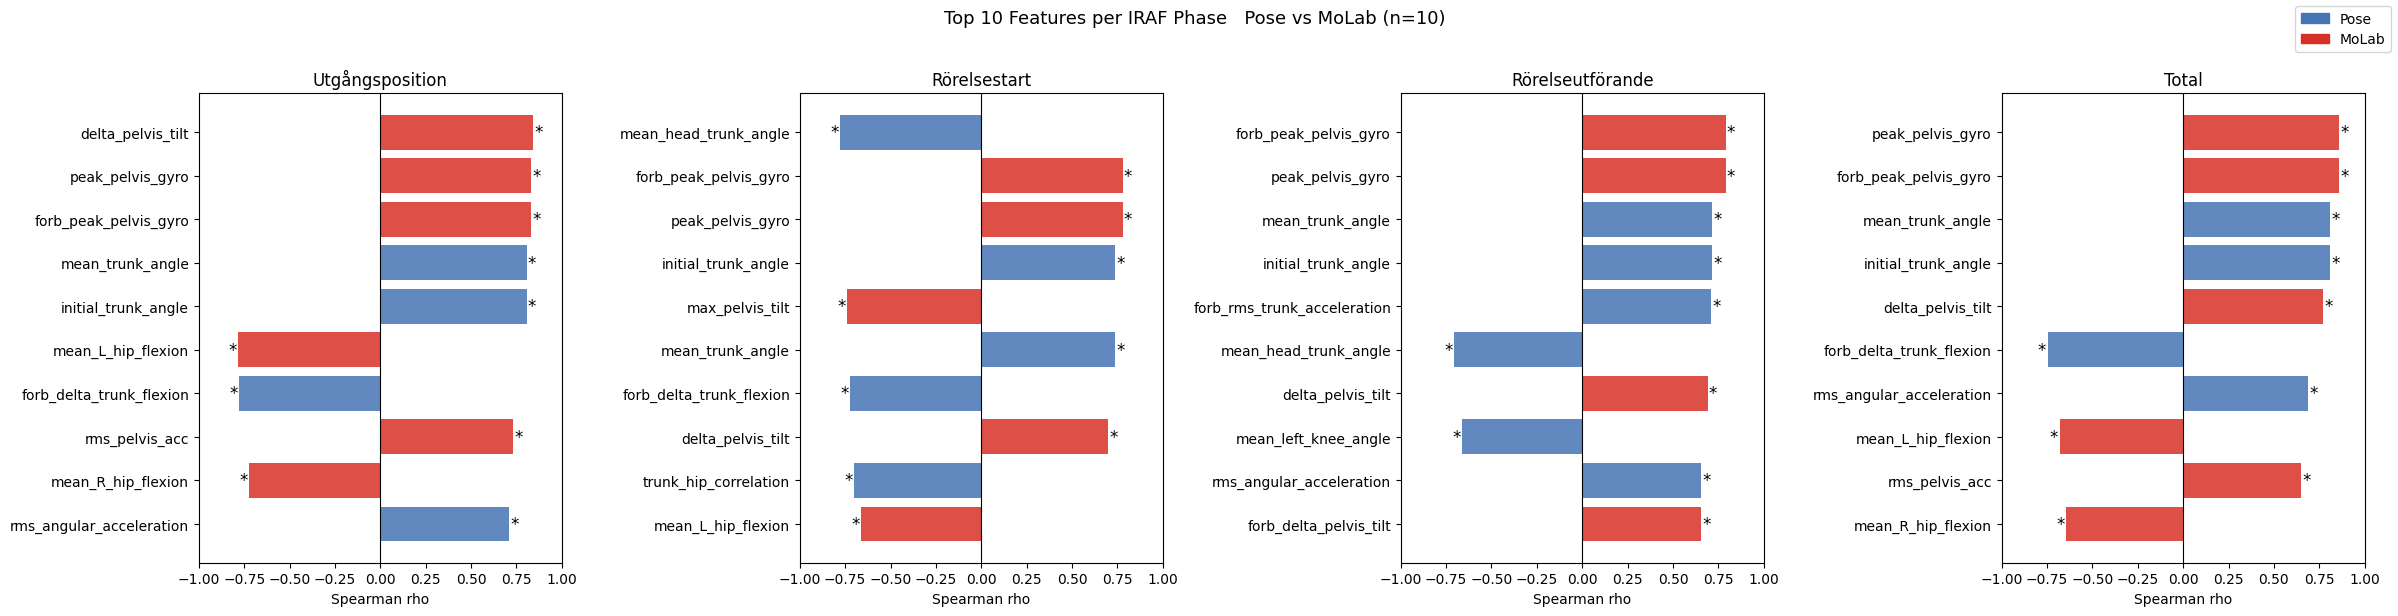

In [4]:
iraf_order = ['iraf_utgångsposition', 'iraf_rörelsestart', 'iraf_rörelseutförande', 'iraf_total']
iraf_titles = ['Utgångsposition', 'Rörelsestart', 'Rörelseutförande', 'Total']

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for ax, ic, title in zip(axes, iraf_order, iraf_titles):
    sub = combined[combined['iraf_score'] == ic].copy()
    sub = sub.assign(abs_rho=sub['spearman_rho'].abs()).sort_values('abs_rho', ascending=False).head(10)
    colors = ['#4575b4' if s == 'Pose' else '#d73027' for s in sub['source']]
    ax.barh(sub['feature'], sub['spearman_rho'], color=colors, alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Spearman rho')
    ax.set_title(title)
    ax.invert_yaxis()
    for i, (_, row) in enumerate(sub.iterrows()):
        if row['p_value'] < 0.05:
            ax.text(row['spearman_rho'] + (0.03 if row['spearman_rho'] >= 0 else -0.03),
                    i, '*', ha='center', va='center', fontsize=12)

from matplotlib.patches import Patch
legend = [Patch(color='#4575b4', label='Pose'), Patch(color='#d73027', label='MoLab')]
fig.legend(handles=legend, loc='upper right', fontsize=10)
plt.suptitle('Top 10 Features per IRAF Phase   Pose vs MoLab (n=10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR + 'combined_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()


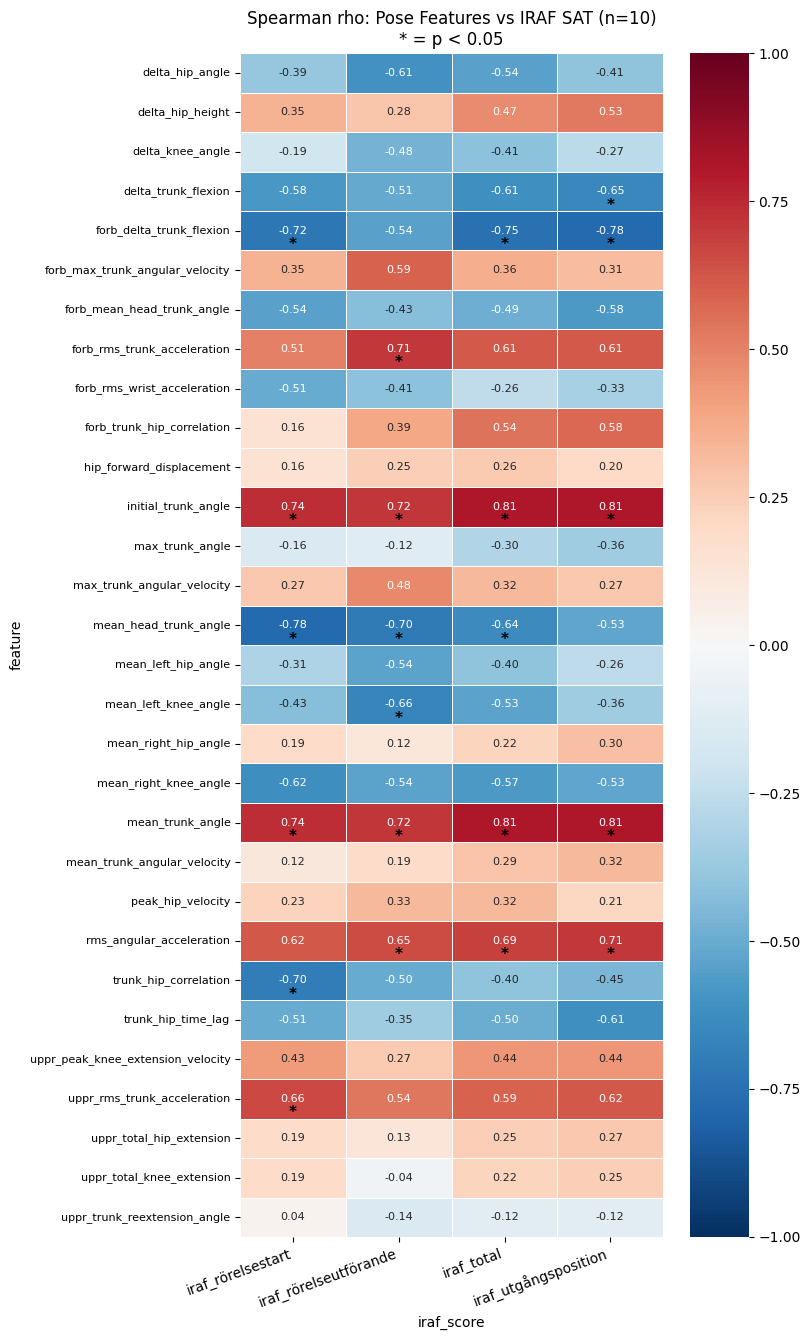

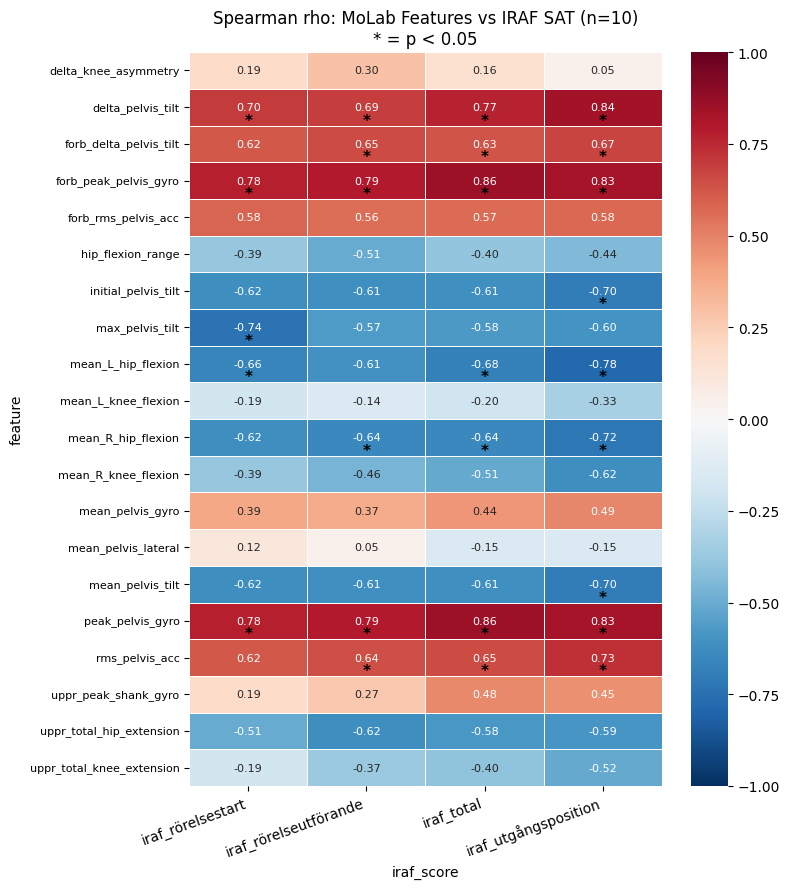

In [5]:
for source_name, df_src in [('Pose', pose), ('MoLab', molab)]:
    pivot   = df_src.pivot_table(index='feature', columns='iraf_score', values='spearman_rho')
    p_pivot = df_src.pivot_table(index='feature', columns='iraf_score', values='p_value')

    fig, ax = plt.subplots(figsize=(8, max(6, len(pivot) * 0.45)))
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
                ax=ax, linewidths=0.5, mask=pivot.isna(), annot_kws={'size': 8})
    for i, feat in enumerate(pivot.index):
        for j, ic in enumerate(pivot.columns):
            if pd.notna(p_pivot.loc[feat, ic]) and p_pivot.loc[feat, ic] < 0.05:
                ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center', fontsize=11, fontweight='bold')
    ax.set_title(f'Spearman rho: {source_name} Features vs IRAF SAT (n=10)\n* = p < 0.05', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR + f'combined_{source_name.lower()}_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
